In [2]:
# Baseline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import set_config
set_config(display = 'diagram')

# Sklearn preprocessing
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler

# Sklearn pipelines
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.pipeline import make_pipeline, Pipeline

# Sklearn model selection
from scipy import stats
from sklearn.metrics import make_scorer, mean_squared_error, mean_squared_log_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate

In [3]:
# models
from sklearn.ensemble import AdaBoostRegressor,GradientBoostingRegressor, StackingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge, LinearRegression, SGDRegressor, BayesianRidge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Load Dataset

In [4]:
df = pd.read_csv('../data/ml/ml_campaign_raw.csv')
df.head()

,CAMPAIGN_ID,CAMPAIGN_NAME,CAMPAIGN_TYPE,PRODUCT_CATEGORY,TARGET_AUDIENCE,START_DATE,END_DATE,REGION,BUDGET,REACH,...,PCT_MARIES,PCT_CELIBATAIRES,NB_VENTES_REGION_MOIS,CA_REGION_MOIS,PANIER_MOYEN_REGION_MOIS,NB_PROMOS_REGION_MOIS,DISCOUNT_MOYEN_REGION_MOIS,NB_AUTRES_CAMPAGNES_MOIS,BUDGET_TOTAL_REGION_MOIS,REACH_TOTAL_REGION_MOIS
0,CAMP23170,"Howard, Ochoa and Myers",Influencer,Clothing,Families,2013-02-27,2013-03-01,North America,171655.70,613432,...,25.6,25.1,2.0,7777.66,3888.83,0.0,0.0,3.0,845275.10,1414584.0
1,CAMP60979,Chen and Sons,Social Media,Beverages,Young Adults,2010-11-17,2010-12-01,South America,394675.12,931148,...,25.5,29.8,2.0,7968.70,3984.35,0.0,0.0,3.0,1031787.58,1657450.0
2,CAMP15002,Nash LLC,Print,Snacks,Seniors,2016-07-17,2016-07-19,Europe,327128.39,874739,...,25.7,23.5,1.0,2043.62,2043.62,0.0,0.0,7.0,2228370.87,4867794.0
3,CAMP31768,Cruz LLC,Radio,Personal Care,Families,2013-08-07,2013-08-14,North America,361672.16,934057,...,25.6,25.1,1.0,2145.85,2145.85,0.0,0.0,12.0,3687317.18,6896258.0
4,CAMP48275,Cook and Sons,Print,Personal Care,Professionals,2015-05-10,2015-05-11,South America,96731.29,369953,...,25.5,29.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.columns

Index(['CAMPAIGN_ID', 'CAMPAIGN_NAME', 'CAMPAIGN_TYPE', 'PRODUCT_CATEGORY',
       'TARGET_AUDIENCE', 'START_DATE', 'END_DATE', 'REGION', 'BUDGET',
       'REACH', 'CONVERSION_RATE', 'ANNEE', 'MOIS', 'TRIMESTRE',
       'JOUR_SEMAINE', 'DUREE_CAMPAGNE_JOURS', 'MOIS_DEBUT',
       'BUDGET_PER_REACH', 'NB_CLIENTS_REGION', 'REVENU_MOYEN_REGION',
       'PCT_FEMMES', 'PCT_HOMMES', 'PCT_MARIES', 'PCT_CELIBATAIRES',
       'NB_VENTES_REGION_MOIS', 'CA_REGION_MOIS', 'PANIER_MOYEN_REGION_MOIS',
       'NB_PROMOS_REGION_MOIS', 'DISCOUNT_MOYEN_REGION_MOIS',
       'NB_AUTRES_CAMPAGNES_MOIS', 'BUDGET_TOTAL_REGION_MOIS',
       'REACH_TOTAL_REGION_MOIS'],
      dtype='object')

In [6]:
df.describe()

,BUDGET,REACH,CONVERSION_RATE,ANNEE,MOIS,TRIMESTRE,JOUR_SEMAINE,DUREE_CAMPAGNE_JOURS,BUDGET_PER_REACH,NB_CLIENTS_REGION,...,PCT_MARIES,PCT_CELIBATAIRES,NB_VENTES_REGION_MOIS,CA_REGION_MOIS,PANIER_MOYEN_REGION_MOIS,NB_PROMOS_REGION_MOIS,DISCOUNT_MOYEN_REGION_MOIS,NB_AUTRES_CAMPAGNES_MOIS,BUDGET_TOTAL_REGION_MOIS,REACH_TOTAL_REGION_MOIS
count,4861.000000,4861.000000,4861.000000,4861.000000,4861.00000,4861.000000,4861.000000,4861.000000,4861.000000,4861.000000,...,4861.000000,4861.000000,2642.000000,2642.000000,2642.000000,2642.0,2642.0,2642.000000,2.642000e+03,2.642000e+03
mean,254166.929368,502059.534869,0.055040,2013.530549,6.54639,2.513269,2.971816,7.447439,1.745659,714.221354,...,26.790105,25.009278,1.482589,7218.939243,4825.728327,0.0,0.0,8.102952,2.061149e+06,4.090766e+06
std,142960.765768,288687.145265,0.025839,2.280924,3.42674,1.114107,1.999441,4.019854,7.687381,17.406989,...,1.401351,2.060155,0.758069,5164.815478,2557.527299,0.0,0.0,2.617623,7.535314e+05,1.463495e+06
min,5000.690000,1610.000000,0.010000,2010.000000,1.00000,1.000000,0.000000,1.000000,0.006053,683.000000,...,25.500000,23.300000,1.000000,12.200000,12.200000,0.0,0.0,1.000000,8.733653e+04,1.946510e+05
25%,128140.480000,253810.000000,0.032900,2012.000000,4.00000,2.000000,1.000000,4.000000,0.259278,703.000000,...,25.600000,23.500000,1.000000,3403.140000,2886.600000,0.0,0.0,6.000000,1.506452e+06,3.057555e+06
50%,257022.600000,502327.000000,0.055500,2014.000000,7.00000,3.000000,3.000000,7.000000,0.505947,713.000000,...,26.300000,24.400000,1.000000,6471.730000,4850.820000,0.0,0.0,8.000000,2.016650e+06,4.095604e+06
75%,376558.660000,755360.000000,0.077300,2015.000000,10.00000,4.000000,5.000000,11.000000,0.999799,726.000000,...,27.900000,25.100000,2.000000,9473.260000,6850.390000,0.0,0.0,10.000000,2.607965e+06,5.220015e+06
max,499976.280000,999919.000000,0.100000,2017.000000,12.00000,4.000000,6.000000,14.000000,219.907890,741.000000,...,29.600000,29.800000,5.000000,29401.180000,9979.520000,0.0,0.0,16.000000,4.270795e+06,7.069939e+06


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4861 entries, 0 to 4860
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CAMPAIGN_ID                 4861 non-null   object 
 1   CAMPAIGN_NAME               4861 non-null   object 
 2   CAMPAIGN_TYPE               4861 non-null   object 
 3   PRODUCT_CATEGORY            4861 non-null   object 
 4   TARGET_AUDIENCE             4861 non-null   object 
 5   START_DATE                  4861 non-null   object 
 6   END_DATE                    4861 non-null   object 
 7   REGION                      4861 non-null   object 
 8   BUDGET                      4861 non-null   float64
 9   REACH                       4861 non-null   int64  
 10  CONVERSION_RATE             4861 non-null   float64
 11  ANNEE                       4861 non-null   int64  
 12  MOIS                        4861 non-null   int64  
 13  TRIMESTRE                   4861 

# X et y

In [8]:
X = df.drop(columns=['CONVERSION_RATE'])
y = df['CONVERSION_RATE']

# Data splitting

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)

# Preprocessing

In [41]:
X.duplicated().sum()

0

In [42]:
X.isnull().sum().sort_values(ascending=False)

REACH_TOTAL_REGION_MOIS       2219
BUDGET_TOTAL_REGION_MOIS      2219
NB_AUTRES_CAMPAGNES_MOIS      2219
DISCOUNT_MOYEN_REGION_MOIS    2219
NB_PROMOS_REGION_MOIS         2219
PANIER_MOYEN_REGION_MOIS      2219
CA_REGION_MOIS                2219
NB_VENTES_REGION_MOIS         2219
BUDGET_PER_REACH                 0
PCT_CELIBATAIRES                 0
PCT_MARIES                       0
PCT_HOMMES                       0
PCT_FEMMES                       0
REVENU_MOYEN_REGION              0
NB_CLIENTS_REGION                0
CAMPAIGN_ID                      0
CAMPAIGN_NAME                    0
DUREE_CAMPAGNE_JOURS             0
JOUR_SEMAINE                     0
TRIMESTRE                        0
MOIS                             0
ANNEE                            0
REACH                            0
BUDGET                           0
REGION                           0
END_DATE                         0
START_DATE                       0
TARGET_AUDIENCE                  0
PRODUCT_CATEGORY    

Les colonnes concernées par les nulls sont celles provenant de la table analytics performance_marketing.
Après vérification on constate que toutes les campagnes ne matchent pas avec un mois qui a eu des ventes.

**On conserve donc ces lignes et remplace par 0**

In [43]:
list_cols =['REACH_TOTAL_REGION_MOIS',
   'NB_PROMOS_REGION_MOIS', 
   'CA_REGION_MOIS', 
   'PANIER_MOYEN_REGION_MOIS', 
   'NB_VENTES_REGION_MOIS', 
   'DISCOUNT_MOYEN_REGION_MOIS', 
   'NB_AUTRES_CAMPAGNES_MOIS', 
   'BUDGET_TOTAL_REGION_MOIS'] 

X[list_cols]= X[list_cols].fillna(0)
X.isnull().sum().sort_values(ascending=False)

CAMPAIGN_ID                   0
BUDGET_PER_REACH              0
BUDGET_TOTAL_REGION_MOIS      0
NB_AUTRES_CAMPAGNES_MOIS      0
DISCOUNT_MOYEN_REGION_MOIS    0
NB_PROMOS_REGION_MOIS         0
PANIER_MOYEN_REGION_MOIS      0
CA_REGION_MOIS                0
NB_VENTES_REGION_MOIS         0
PCT_CELIBATAIRES              0
PCT_MARIES                    0
PCT_HOMMES                    0
PCT_FEMMES                    0
REVENU_MOYEN_REGION           0
NB_CLIENTS_REGION             0
MOIS_DEBUT                    0
CAMPAIGN_NAME                 0
DUREE_CAMPAGNE_JOURS          0
JOUR_SEMAINE                  0
TRIMESTRE                     0
MOIS                          0
ANNEE                         0
REACH                         0
BUDGET                        0
REGION                        0
END_DATE                      0
START_DATE                    0
TARGET_AUDIENCE               0
PRODUCT_CATEGORY              0
CAMPAIGN_TYPE                 0
REACH_TOTAL_REGION_MOIS       0
dtype: i

# Feature Engineering

In [44]:
X.CAMPAIGN_TYPE.unique()

array(['Influencer', 'Social Media', 'Print', 'Radio',
       'Content Marketing', 'Email', 'TV'], dtype=object)

In [45]:
def features_engineering(X):
    X = X.copy()
    # Part du budget régional (0 si pas de budget total dans la région)
    X['SHARE_OF_VOICE'] = (X['BUDGET'] / X['BUDGET_TOTAL_REGION_MOIS'].replace(0, np.nan)).fillna(0)
    # Budget quotidien de la campagne
    X['BUDGET_QUOTIDIEN'] = (X['BUDGET'] / X['DUREE_CAMPAGNE_JOURS'].replace(0, np.nan)).fillna(0)
    # Taux de pénétration de la campagne dans la région
    X['REACH_PENETRATION'] = (X['REACH'] / X['NB_CLIENTS_REGION'].replace(0, np.nan)).fillna(0)
    # Effort total de la campagne
    X['EFFORT_TOTAL'] = X['BUDGET'] * X['DUREE_CAMPAGNE_JOURS']

    # Isoler les campagnes digitales
    digital_types = ['Social Media', 'Email', 'Content Marketing', 'Influencer']
    X['IS_DIGITAL'] = X['CAMPAIGN_TYPE'].isin(digital_types).astype(int)

    # Saisonnalité
    X['IS_HOLIDAY_SEASON'] = X['MOIS'].isin([11, 12]).astype(int)
    X['IS_SUMMER'] = X['MOIS'].isin([6, 7, 8]).astype(int)
    X['IS_WINTER'] = X['MOIS'].isin([12, 1, 2]).astype(int)
    return X

In [46]:
feature_engineer = FunctionTransformer(features_engineering)

# Scaling

## Traiter les valeurs numériques

In [47]:
num_cols = X.select_dtypes(exclude='object').columns

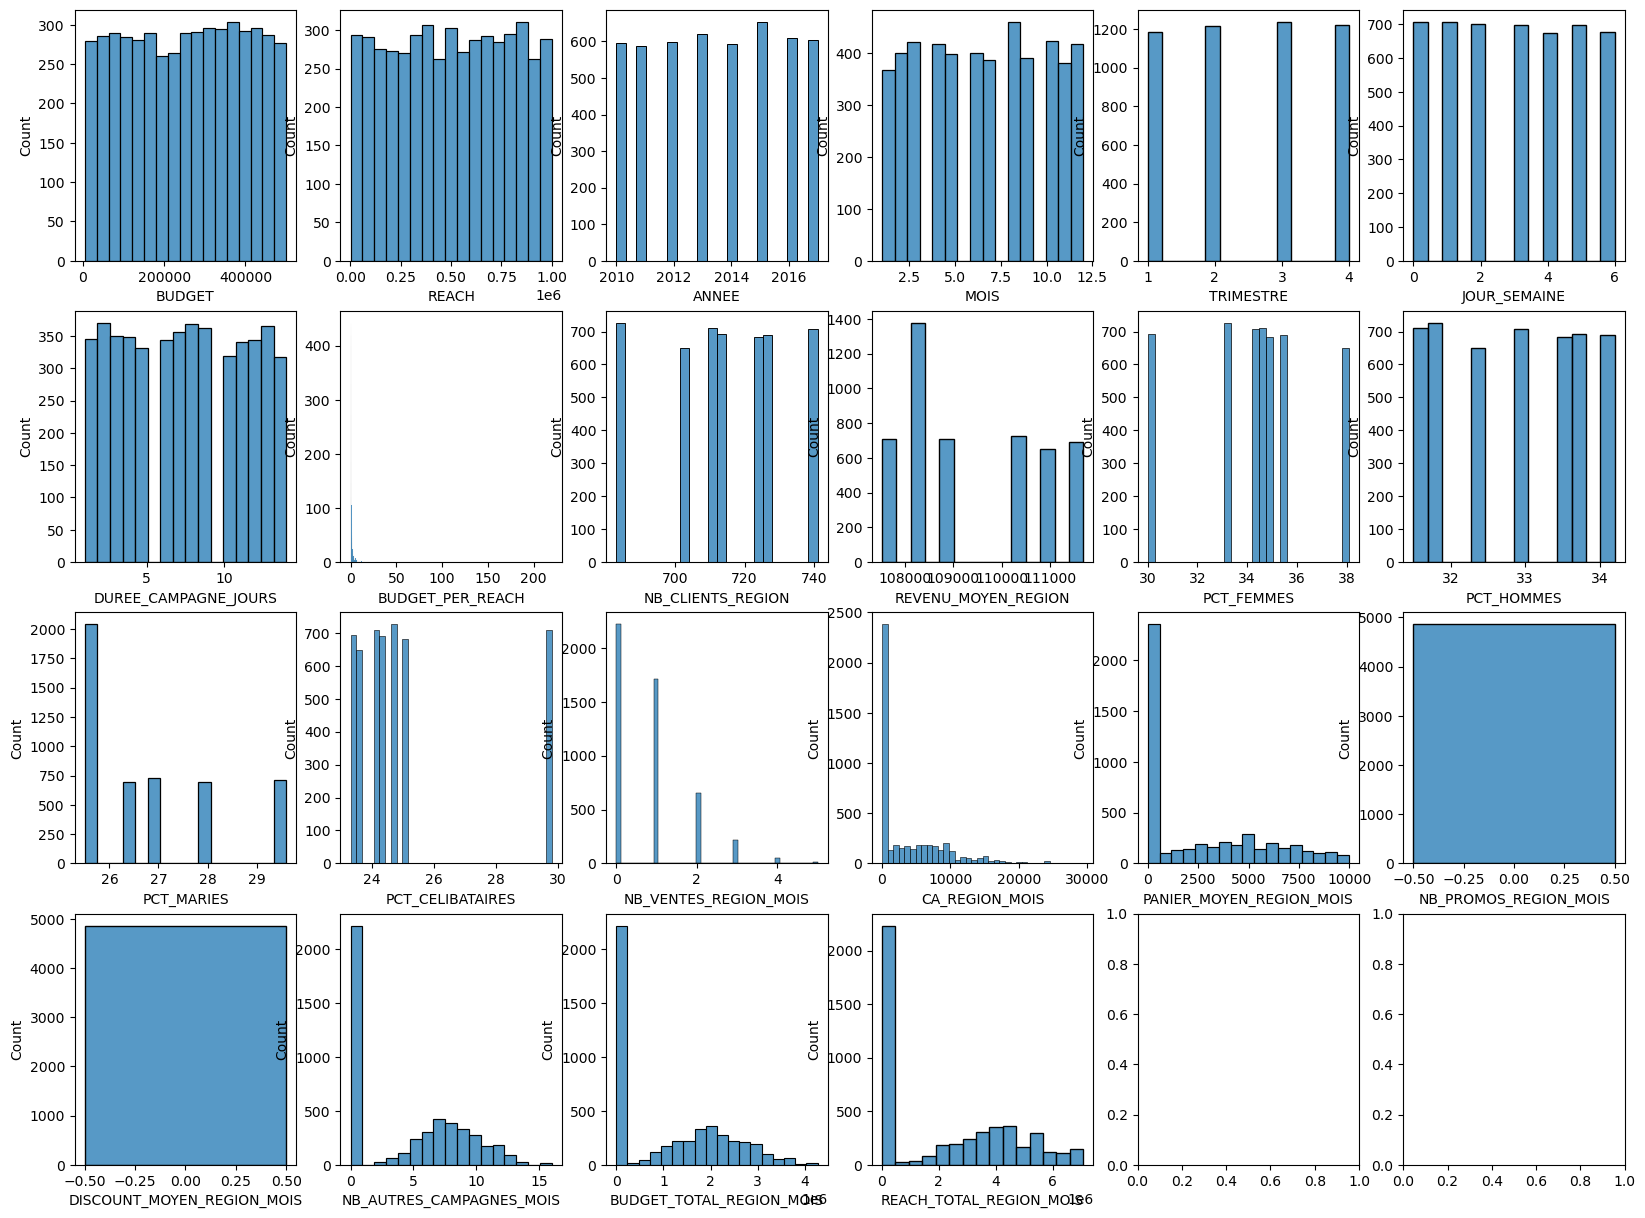

In [48]:
fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 15))

for col, ax in zip(num_cols, axes.ravel()):
    sns.histplot(X[col], ax=ax)


### Analyse des features nums additionnelles

In [49]:
X_additionnal_feat = features_engineering(X)
X_additionnal_feat.columns

Index(['CAMPAIGN_ID', 'CAMPAIGN_NAME', 'CAMPAIGN_TYPE', 'PRODUCT_CATEGORY',
       'TARGET_AUDIENCE', 'START_DATE', 'END_DATE', 'REGION', 'BUDGET',
       'REACH', 'ANNEE', 'MOIS', 'TRIMESTRE', 'JOUR_SEMAINE',
       'DUREE_CAMPAGNE_JOURS', 'MOIS_DEBUT', 'BUDGET_PER_REACH',
       'NB_CLIENTS_REGION', 'REVENU_MOYEN_REGION', 'PCT_FEMMES', 'PCT_HOMMES',
       'PCT_MARIES', 'PCT_CELIBATAIRES', 'NB_VENTES_REGION_MOIS',
       'CA_REGION_MOIS', 'PANIER_MOYEN_REGION_MOIS', 'NB_PROMOS_REGION_MOIS',
       'DISCOUNT_MOYEN_REGION_MOIS', 'NB_AUTRES_CAMPAGNES_MOIS',
       'BUDGET_TOTAL_REGION_MOIS', 'REACH_TOTAL_REGION_MOIS', 'SHARE_OF_VOICE',
       'BUDGET_QUOTIDIEN', 'REACH_PENETRATION', 'EFFORT_TOTAL', 'IS_DIGITAL',
       'IS_HOLIDAY_SEASON', 'IS_SUMMER', 'IS_WINTER'],
      dtype='object')

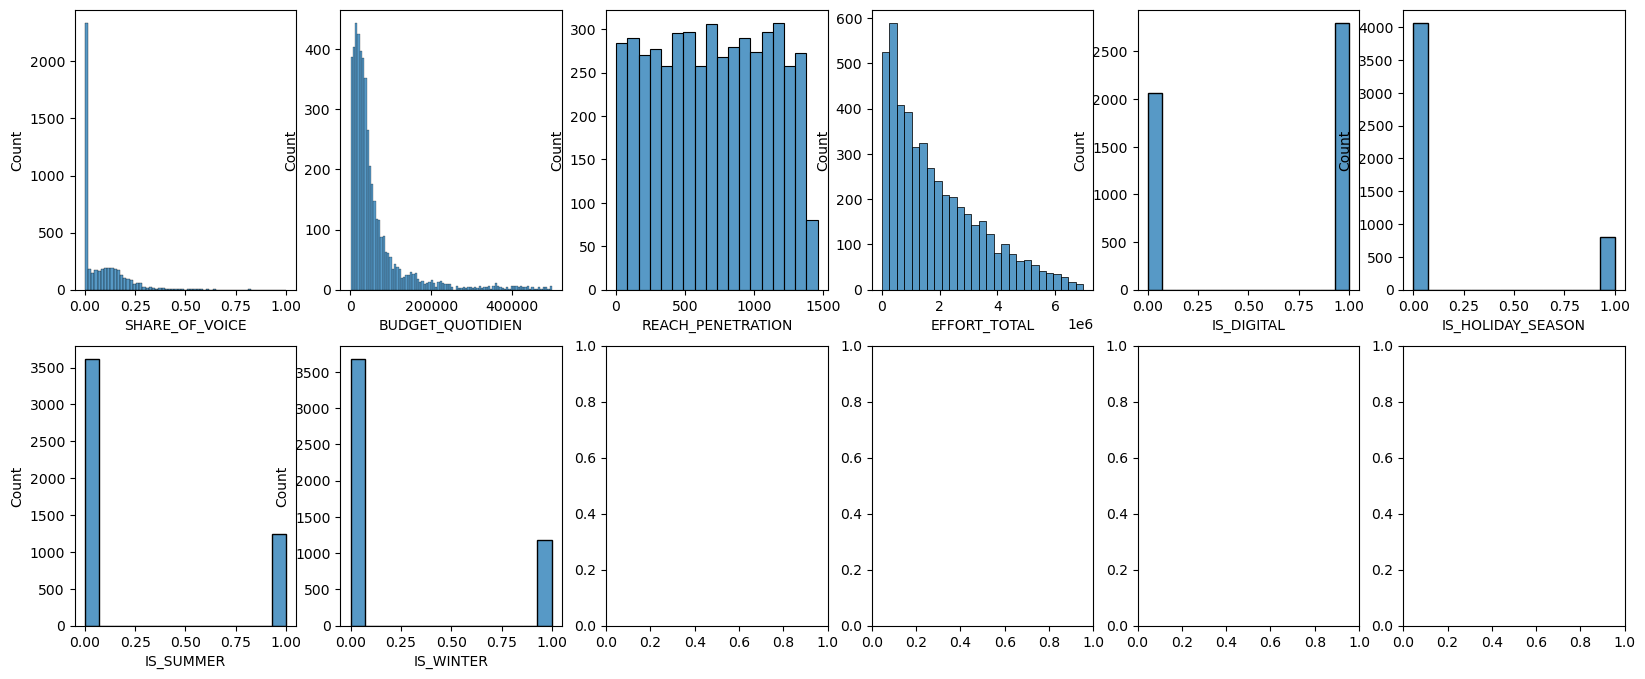

In [50]:

fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(20, 8))

for col, ax in zip(['SHARE_OF_VOICE',
       'BUDGET_QUOTIDIEN', 'REACH_PENETRATION', 'EFFORT_TOTAL', 'IS_DIGITAL',
       'IS_HOLIDAY_SEASON', 'IS_SUMMER', 'IS_WINTER'], axes.ravel()):
    sns.histplot(X_additionnal_feat[col], ax=ax)

In [51]:
robust_feat =['BUDGET_PER_REACH', 'PCT_MARIES', 'PCT_CELIBATAIRES', 'NB_VENTES_REGION_MOIS', 'CA_REGION_MOIS', 'PANIER_MOYEN_REGION_MOIS', 'NB_AUTRES_CAMPAGNES_MOIS', 'REACH_TOTAL_REGION_MOIS', 'BUDGET_TOTAL_REGION_MOIS', 'SHARE_OF_VOICE', 'BUDGET_QUOTIDIEN', 'EFFORT_TOTAL']
standard_feat =['BUDGET','REACH', 'DUREE_CAMPAGNE_JOURS', 'NB_CLIENTS_REGION', 'REVENU_MOYEN_REGION', 'PCT_FEMMES', 'PCT_HOMMES', 'NB_PROMOS_REGION_MOIS', 'DISCOUNT_MOYEN_REGION_MOIS',  'REACH_PENETRATION']
not_to_scale = ['ANNEE', 'MOIS', 'TRIMESTRE', 'JOUR_SEMAINE', 'IS_DIGITAL', 'IS_HOLIDAY_SEASON', 'IS_SUMMER', 'IS_WINTER']

In [52]:
len(robust_feat) + len(standard_feat) + len(not_to_scale)

30

On a bien toutes nos colonnes numériques feature engineering compris

In [53]:
preproc_num = make_column_transformer(
    (StandardScaler(), standard_feat),
    (RobustScaler(), robust_feat),
    ('passthrough', not_to_scale),
    remainder='drop'
)
preproc_num

ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                 ['BUDGET', 'REACH', 'DUREE_CAMPAGNE_JOURS',
                                  'NB_CLIENTS_REGION', 'REVENU_MOYEN_REGION',
                                  'PCT_FEMMES', 'PCT_HOMMES',
                                  'NB_PROMOS_REGION_MOIS',
                                  'DISCOUNT_MOYEN_REGION_MOIS',
                                  'REACH_PENETRATION']),
                                ('robustscaler', RobustScaler(),
                                 ['BUDGET_PER_REACH', 'PCT_MARIES',
                                  'PCT_CELIBATAIRES', 'NB_VENTES_REGION_MOIS',
                                  'CA_REGION_MOIS', 'PANIER_MOYEN_REGION_MOIS',
                                  'NB_AUTRES_CAMPAGNES_MOIS',
                                  'REACH_TOTAL_REGION_MOIS',
                                  'BUDGET_TOTAL_REGION_MOIS', 'SHARE_OF_VOICE',
                                  'BUDGET_QUOTIDIEN', 'EFFORT_TOTAL']),
                                ('passthrough', 'passthrough',
                                 ['ANNEE', 'MOIS', 'TRIMESTRE', 'JOUR_SEMAINE',
                                  'IS_DIGITAL', 'IS_HOLIDAY_SEASON',
                                  'IS_SUMMER', 'IS_WINTER'])])

## Traiter les valeurs catégoriques

In [54]:
X.select_dtypes(include='object').columns

Index(['CAMPAIGN_ID', 'CAMPAIGN_NAME', 'CAMPAIGN_TYPE', 'PRODUCT_CATEGORY',
       'TARGET_AUDIENCE', 'START_DATE', 'END_DATE', 'REGION', 'MOIS_DEBUT'],
      dtype='object')

In [55]:
X.CAMPAIGN_TYPE.unique()

array(['Influencer', 'Social Media', 'Print', 'Radio',
       'Content Marketing', 'Email', 'TV'], dtype=object)

In [56]:
X.PRODUCT_CATEGORY.unique()

array(['Clothing', 'Beverages', 'Snacks', 'Personal Care', 'Household',
       'Electronics', 'Baby Food'], dtype=object)

In [57]:
X.TARGET_AUDIENCE.unique()

array(['Families', 'Young Adults', 'Seniors', 'Professionals', 'Students'],
      dtype=object)

In [58]:
X.REGION.unique()

array(['North America', 'South America', 'Europe', 'Asia', 'Africa',
       'Middle East and North Africa', 'Oceania'], dtype=object)

In [59]:
cat_cols = ['CAMPAIGN_TYPE', 'PRODUCT_CATEGORY', 'TARGET_AUDIENCE', 'REGION']

In [60]:
preproc_cat = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), cat_cols),
    remainder='drop'
)
preproc_cat

ColumnTransformer(transformers=[('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['CAMPAIGN_TYPE', 'PRODUCT_CATEGORY',
                                  'TARGET_AUDIENCE', 'REGION'])])

# Pipeline complet

In [61]:
scaling_encoding = make_column_transformer(
    (StandardScaler(), standard_feat),
    (RobustScaler(), robust_feat),
    ('passthrough', not_to_scale),
    (OneHotEncoder(handle_unknown='ignore'), cat_cols),
    remainder='drop'
)

preproc = Pipeline([
    ('feature_engineering', feature_engineer),
    ('scaling_encoding', scaling_encoding)
])

preproc

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function features_engineering at 0x0000023DB0A80D60>)),
                ('scaling_encoding',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['BUDGET', 'REACH',
                                                   'DUREE_CAMPAGNE_JOURS',
                                                   'NB_CLIENTS_REGION',
                                                   'REVENU_MOYEN_REGION',
                                                   'PCT_FEMMES', 'PCT_HOMMES',
                                                   'NB_PROMOS_REGION_MOIS',
                                                   'DISCOUNT_MOY...
                                                   'REACH_TOTAL_REGION_MOIS',
                                                   'BUDGET_TOTAL_REGION_MOIS',
                                                   'SHARE_OF_VOICE',
                                                   'BUDGET_QUOTIDIEN',
                                                   'EFFORT_TOTAL']),
                                                 ('passthrough', 'passthrough',
                                                  ['ANNEE', 'MOIS', 'TRIMESTRE',
                                                   'JOUR_SEMAINE', 'IS_DIGITAL',
                                                   'IS_HOLIDAY_SEASON',
                                                   'IS_SUMMER', 'IS_WINTER']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['CAMPAIGN_TYPE',
                                                   'PRODUCT_CATEGORY',
                                                   'TARGET_AUDIENCE',
                                                   'REGION'])]))])

In [62]:
preproc.fit_transform(X).shape, preproc.fit_transform(X)

((4861, 56),
 array([[-0.57721933,  0.38582917, -1.35527307, ...,  1.        ,
          0.        ,  0.        ],
        [ 0.98294553,  1.48649711,  1.63021743, ...,  0.        ,
          0.        ,  1.        ],
        [ 0.51041253,  1.29107863, -1.35527307, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [-1.15013523, -1.20865938,  0.38626306, ...,  0.        ,
          1.        ,  0.        ],
        [ 1.06503537,  1.57830836, -0.11131869, ...,  0.        ,
          1.        ,  0.        ],
        [-0.23793177, -1.43824985,  0.38626306, ...,  1.        ,
          0.        ,  0.        ]]))

# Baseline

Création de la baseline, modèle de référence pour la suite

In [66]:
pipe_baseline = make_pipeline(preproc, 
                             LinearRegression())
pipe_baseline

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('feature_engineering',
                                  FunctionTransformer(func=<function features_engineering at 0x0000023DB0A80D60>)),
                                 ('scaling_encoding',
                                  ColumnTransformer(transformers=[('standardscaler',
                                                                   StandardScaler(),
                                                                   ['BUDGET',
                                                                    'REACH',
                                                                    'DUREE_CAMPAGNE_JOURS',
                                                                    'NB_CLIENTS_REGION',
                                                                    'REVENU_MOYEN_REGION',
                                                                    'PCT_FEMMES',
                                                                    'PCT_HOMMES',
                                                                    'NB_PROMO...
                                                                    'SHARE_OF_VOICE',
                                                                    'BUDGET_QUOTIDIEN',
                                                                    'EFFORT_TOTAL']),
                                                                  ('passthrough',
                                                                   'passthrough',
                                                                   ['ANNEE',
                                                                    'MOIS',
                                                                    'TRIMESTRE',
                                                                    'JOUR_SEMAINE',
                                                                    'IS_DIGITAL',
                                                                    'IS_HOLIDAY_SEASON',
                                                                    'IS_SUMMER',
                                                                    'IS_WINTER']),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'),
                                                                   ['CAMPAIGN_TYPE',
                                                                    'PRODUCT_CATEGORY',
                                                                    'TARGET_AUDIENCE',
                                                                    'REGION'])]))])),
                ('linearregression', LinearRegression())])

## Cross-validation

In [67]:
cv_baseline = cross_validate(pipe_baseline, X, y, scoring='r2', cv=5)
cv_baseline

{'fit_time': array([0.34702396, 0.03650832, 0.03597212, 0.03651404, 0.0330019 ]),
 'score_time': array([0.01500487, 0.01100564, 0.0150094 , 0.012995  , 0.01403165]),
 'test_score': array([-0.01892737, -0.0097162 , -0.00970468, -0.0090502 , -0.00850728])}

In [69]:
df_corr = df.select_dtypes(include=[np.number])
correlations = df_corr.corr()['CONVERSION_RATE'].sort_values(ascending=False)
correlations


CONVERSION_RATE               1.000000
ANNEE                         0.024204
NB_AUTRES_CAMPAGNES_MOIS      0.022008
PCT_MARIES                    0.018302
REACH_TOTAL_REGION_MOIS       0.015735
PCT_HOMMES                    0.014879
NB_CLIENTS_REGION             0.014285
REACH                         0.008721
JOUR_SEMAINE                  0.007042
PCT_CELIBATAIRES              0.006596
BUDGET_TOTAL_REGION_MOIS      0.002508
DUREE_CAMPAGNE_JOURS          0.002202
BUDGET_PER_REACH              0.000794
TRIMESTRE                    -0.005164
BUDGET                       -0.006695
MOIS                         -0.006726
PANIER_MOYEN_REGION_MOIS     -0.012211
NB_VENTES_REGION_MOIS        -0.012301
CA_REGION_MOIS               -0.016672
REVENU_MOYEN_REGION          -0.025104
PCT_FEMMES                   -0.035925
NB_PROMOS_REGION_MOIS              NaN
DISCOUNT_MOYEN_REGION_MOIS         NaN
Name: CONVERSION_RATE, dtype: float64

Le test de la baseline et la vérification de corrélation des features avec la target montre des résultats décevants.

Il semble que la colonne CONVERSION_RATE soit créée aléatoirement.

# Test de plusieurs modèles différents

In [70]:
final_scores = {
    'model_name': [],
    'score': [],
    'log': []
}

final_scores['model_name'].append('baseline')
final_scores['score'].append(cv_baseline['test_score'].mean())
#final_scores['log'].append(False)
final_scores

{'model_name': ['baseline'], 'score': [-0.01118114759432567], 'log': []}

In [77]:
models = [Ridge(), BayesianRidge(),
          SVR(),
          RandomForestRegressor(), AdaBoostRegressor(), GradientBoostingRegressor() ,
         XGBRegressor()
         ]

In [79]:
final_scores = {'model_name': [], 'score': [], 'log': []}

for model in models:
    model_name = str(model)[:-2]
    print(f'Starting cv of model {model_name}')
    
    pipe = make_pipeline(preproc, model)
    cv_res = cross_validate(pipe, X, y, scoring='r2', cv=5)
    
    # Ajouter aux listes APRÈS le succès du cross_validate
    final_scores['model_name'].append(model_name)
    final_scores['score'].append(cv_res['test_score'].mean())
    final_scores['log'].append(False)

pd.DataFrame(final_scores).sort_values(by='score', ascending=False)


Starting cv of model Ridge
Starting cv of model BayesianRidge
Starting cv of model SVR
Starting cv of model RandomForestRegressor
Starting cv of model AdaBoostRegressor
Starting cv of model GradientBoostingRegressor
Starting cv of model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ..


,model_name,score,log
2,SVR,-0.000418,False
4,AdaBoostRegressor,-0.003522,False
1,BayesianRidge,-0.003814,False
0,Ridge,-0.011106,False
5,GradientBoostingRegressor,-0.028060,False
3,RandomForestRegressor,-0.044857,False
6,"XGBRegressor(base_score=None, booster=None, ca...",-0.222359,False


<Axes: xlabel='CONVERSION_RATE', ylabel='Count'>

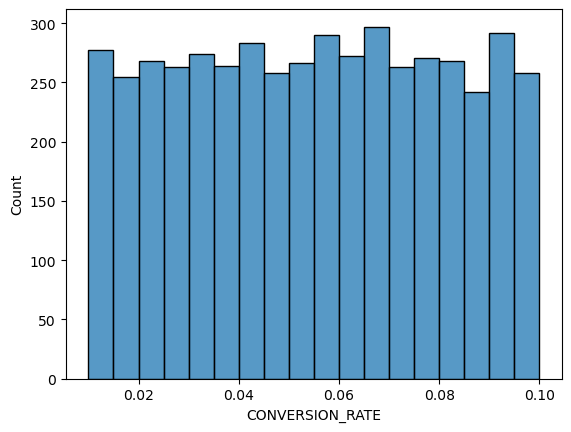

In [9]:
sns.histplot(y)